In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
import os


In [3]:
img_size = 224  # MobileNetV2 input size

train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True, zoom_range=0.2)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_dir = r'C:\Users\Admin\OneDrive\Documents\Fruits Classification\train'
val_dir = r'C:\Users\Admin\OneDrive\Documents\Fruits Classification\valid'
test_dir = r'C:\Users\Admin\OneDrive\Documents\Fruits Classification\test'

train_generator = train_datagen.flow_from_directory(train_dir, target_size=(img_size, img_size), batch_size=32, class_mode='categorical')
val_generator = val_datagen.flow_from_directory(val_dir, target_size=(img_size, img_size), batch_size=32, class_mode='categorical')
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(img_size, img_size), batch_size=32, class_mode='categorical')


Found 7760 images belonging to 4 classes.
Found 160 images belonging to 4 classes.
Found 80 images belonging to 4 classes.


In [9]:
base_model = MobileNetV2(input_shape=(img_size, img_size, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')  # for 4 classes
])

model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [20]:
history = model.fit(train_generator, epochs=5, validation_data=val_generator)


C:\Users\Admin\anaconda3\envs\fruit-detection\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
243/243 ━━━━━━━━━━━━━━━━━━━━ 500s 2s/step - accuracy: 0.7278 - loss: 0.7038 - val_accuracy: 0.8250 - val_loss: 0.4460
Epoch 2/5
243/243 ━━━━━━━━━━━━━━━━━━━━ 362s 1s/step - accuracy: 0.8407 - loss: 0.4372 - val_accuracy: 0.8562 - val_loss: 0.4039
Epoch 3/5
243/243 ━━━━━━━━━━━━━━━━━━━━ 345s 1s/step - accuracy: 0.8686 - loss: 0.3588 - val_accuracy: 0.8813 - val_loss: 0.3515
Epoch 4/5
243/243 ━━━━━━━━━━━━━━━━━━━━ 386s 1s/step - accuracy: 0.8781 - loss: 0.3239 - val_accuracy: 0.8687 - val_loss: 0.3544
Epoch 5/5
243/243 ━━━━━━━━━━━━━━━━━━━━ 347s 1s/step - accuracy: 0.8933 - loss: 0.2957 - val_accuracy: 0.9125 - val_loss: 0.3340


In [11]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.2f}")


C:\Users\Admin\anaconda3\envs\fruit-detection\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 831ms/step - accuracy: 0.2961 - loss: 1.6792
Test Accuracy: 0.29


In [12]:
model.save('my_model.keras')


In [15]:
from tensorflow.keras.models import load_model

model = load_model(r'C:\Users\Admin\OneDrive\Documents\Fruits Classification\my_model.keras')


C:\Users\Admin\anaconda3\envs\fruit-detection\lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Found 80 images belonging to 4 classes.
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step  


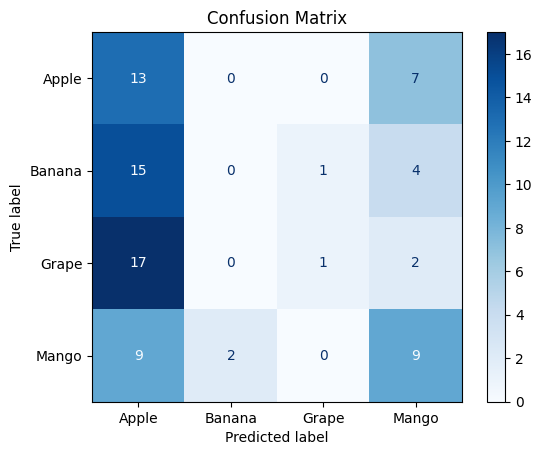

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# === Reload test generator ===
test_dir = r"C:\Users\Admin\OneDrive\Documents\Fruits Classification\test"  # <-- change if needed

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# === Predict and Get Confusion Matrix ===
Y_true = test_generator.classes
Y_pred_prob = model.predict(test_generator)
Y_pred = np.argmax(Y_pred_prob, axis=1)

# Class names
class_labels = list(test_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(Y_true, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


In [21]:
class_indices = test_generator.class_indices
# Invert the dictionary: {0: 'apple', 1: 'banana', ...}
class_names = {v: k for k, v in class_indices.items()}


In [33]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing import image

# Open webcam
cap = cv2.VideoCapture(0)
print("Press SPACE to capture the image or ESC to exit")

while True:
    ret, frame = cap.read()
    if not ret:
        print("Failed to grab frame")
        break

    cv2.imshow("Webcam - Press SPACE to capture", frame)

    k = cv2.waitKey(1)
    if k % 256 == 27:
        # ESC pressed
        print("Closing camera.")
        break
    elif k % 256 == 32:
        # SPACE pressed — capture image
        img = cv2.resize(frame, (224, 224))
        img_array = image.img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Predict
        pred = model.predict(img_array)
        predicted_index = np.argmax(pred)
        predicted_class = class_names[predicted_index]
        print(f"Fruit name is : {predicted_class}")
        break

cap.release()
cv2.destroyAllWindows()



Press SPACE to capture the image or ESC to exit
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Fruit name is : Apple


In [25]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Load and preprocess image
img_path = r"C:\Users\Admin\OneDrive\Documents\photo3.jpg"  # Replace with your image path
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]

print(f"Predicted class: {predicted_class}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted class: Banana


In [42]:
print(train_generator.class_indices)


{'Apple': 0, 'Banana': 1, 'Grape': 2, 'Mango': 3}
